# Credit Card Customer Clustering

This notebook groups credit card customers into segments using K-Means, DBSCAN, and Agglomerative Clustering.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.style.use("seaborn-v0_8-whitegrid")


def find_data_file(*relative_paths: str) -> Path:
    """Find a data file from the notebook folder or one of its parent folders."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        for rel_path in relative_paths:
            candidate = (root / rel_path).resolve()
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Could not find any of: {relative_paths}")


# Locate the customer dataset from the exercise folder or the repository root.
data_path = find_data_file(
    "data/CC_GENERAL.csv",
    "data/CC GENERAL.csv",
    "exercises/data/CC_GENERAL.csv",
    "exercises/data/CC GENERAL.csv",
)

df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)

Dataset shape: (8950, 18)


In [2]:
# Inspect the raw dataset before cleaning and clustering.
display(df.describe().T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000



Missing values:


MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
CUST_ID                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_TRX                         0
PAYMENTS                              0
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

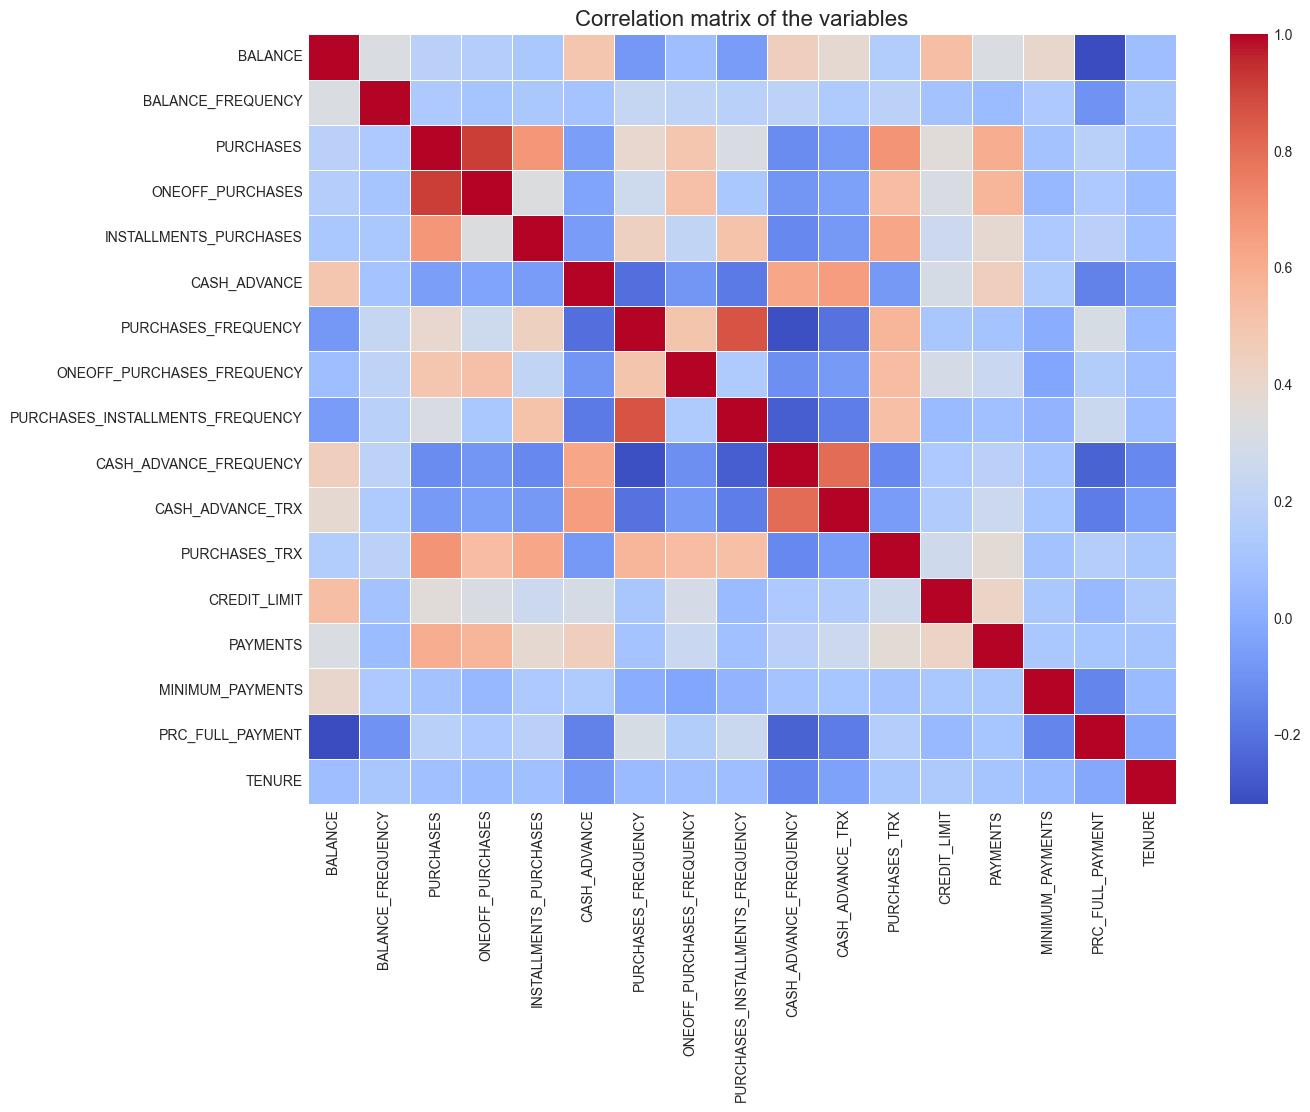

In [3]:
# Visualize pairwise correlations to identify redundant customer behavior variables.
plt.figure(figsize=(14, 10))

sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation matrix of the variables", fontsize=16)
plt.show()

In [4]:
# Impute missing values and standardize the numerical features before clustering.
df_num = df.drop(columns=["CUST_ID"]).copy()

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_num), columns=df_num.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

In [5]:
# Use silhouette scores to choose a reasonable number of K-Means clusters.
k_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    k_scores.append((k, silhouette_score(X_scaled, labels)))

score_df = pd.DataFrame(k_scores, columns=["k", "Silhouette score"])
display(score_df)

best_k = int(score_df.sort_values("Silhouette score", ascending=False).iloc[0]["k"])
print("Selected number of clusters for K-Means:", best_k)

,k,Silhouette score
0,2,0.209763
1,3,0.250252
2,4,0.197529
3,5,0.192743
4,6,0.202542
5,7,0.214805
6,8,0.221607


Selected number of clusters for K-Means: 3


In [6]:
# Fit three clustering algorithms for comparison.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.6, min_samples=20)
dbscan_labels = dbscan.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=best_k)
agglo_labels = agglo.fit_predict(X_scaled)

In [7]:
# Summarize the clustering quality with standard unsupervised metrics.
def evaluate_clustering(X, labels, model_name):
    unique_labels = np.unique(labels)
    n_clusters = len([lab for lab in unique_labels if lab != -1])
    if n_clusters < 2:
        return {
            "Model": model_name,
            "Clusters": n_clusters,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
        }
    return {
        "Model": model_name,
        "Clusters": n_clusters,
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
    }

results = pd.DataFrame([
    evaluate_clustering(X_scaled, kmeans_labels, "K-Means"),
    evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN"),
    evaluate_clustering(X_scaled, agglo_labels, "Agglomerative Clustering"),
])

display(results)

,Model,Clusters,Silhouette,Davies-Bouldin
0,K-Means,3,0.250252,1.597762
1,DBSCAN,1,NaN,NaN
2,Agglomerative Clustering,3,0.192380,1.746847


In [8]:
# Profile the K-Means segments to interpret the customer groups.
profile_df = df_imputed.copy()
profile_df["cluster"] = kmeans_labels

cluster_profile = profile_df.groupby("cluster").mean().round(2)
display(cluster_profile)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,3995.17,0.96,385.50,249.20,136.38,3869.03,0.23,0.11,0.15,0.45,12.41,5.64,6683.62,3020.38,1814.69,0.03,11.35
1,2197.30,0.98,4233.04,2697.66,1535.86,455.60,0.95,0.67,0.74,0.06,1.52,56.11,7687.66,4118.08,1215.04,0.30,11.92
2,800.45,0.83,502.02,250.26,252.07,332.04,0.46,0.13,0.34,0.07,1.21,8.59,3267.97,908.16,527.40,0.15,11.48


## Interpretation

The clusters can usually be interpreted as broad customer profiles, such as low-usage customers, active purchasers, cash-advance-heavy customers, and more premium users.

This type of segmentation can support targeted marketing and more focused risk management.